In [ ]:
import wradlib as wrl
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.interpolate import RegularGridInterpolator

def maxcappi_from_wradlib(filepath, scan_key="SCAN0", moment_key="ZH", x=None, y=None, z=None, stretch=1, limits=None, colormap='viridis', interp='linear'):
    """
    Generates a MaxCAPPI visualization from radar data using wradlib.

    Parameters:
        filepath (str): Path to the HDF5 file.
        scan_key (str): Key for the scan in the HDF5 file (e.g., "SCAN0").
        moment_key (str): Key for the radar moment (e.g., "ZH").
        x (array): Horizontal axis 1 (longitude or x-coordinate).
        y (array): Horizontal axis 2 (latitude or y-coordinate).
        z (array): Vertical axis (heights in meters).
        stretch (float): Stretch factor for visualization.
        limits (array): Value limits for the colormap.
        colormap (str): Colormap for visualization.
        interp (str): Interpolation method ('linear', 'nearest').

    Returns:
        None: Displays the MaxCAPPI visualization.
    """
    # Read radar data using wradlib
    os.environ['WRADLIB_DATA'] = 'wradlib_data'
    f = wrl.util.get_wradlib_data_file(fpath)
    data, metadata = wrl.io.read_gamic_hdf5(f)
    reflectivity = data[scan_key][moment_key]["data"]  # Extract reflectivity data
    # Extract azimuth angles (adjust key access based on the data structure)
    azimuths = data[scan_key].get("azimuth", {}).get("data", None)
    if azimuths is None:
        raise KeyError("The key 'azimuth' is not found in the radar data. Please check the data structure.")
    ranges = data[scan_key]["r"]["data"]  # Range bins
    elevations = data[scan_key]["elevation"]["data"]  # Elevation angles

    # Convert polar coordinates to Cartesian coordinates
    x_coords, y_coords, z_coords = wrl.georef.spherical_to_xyz(ranges, azimuths, elevations, sitecoords=(0, 0, 0))

    # Set default axes if not provided
    if x is None:
        x = np.linspace(np.min(x_coords), np.max(x_coords), reflectivity.shape[1])
    if y is None:
        y = np.linspace(np.min(y_coords), np.max(y_coords), reflectivity.shape[2])
    if z is None:
        z = np.arange(250, 10000 + 250, 250)  # Default heights in meters

    # Create a grid for interpolation
    grid_x, grid_y, grid_z = np.meshgrid(x, y, z, indexing='ij')

    # Interpolate data onto the grid
    interpolator = RegularGridInterpolator(
        (x_coords[:, 0, 0], y_coords[0, :, 0], z_coords[0, 0, :]),
        reflectivity,
        method=interp,
        bounds_error=False,
        fill_value=np.nan
    )
    points = np.array([grid_x.ravel(), grid_y.ravel(), grid_z.ravel()]).T
    interpolated_data = interpolator(points).reshape(grid_x.shape)

    # Compute the maximum reflectivity along the vertical axis
    max_reflectivity = np.nanmax(interpolated_data, axis=2)

    # Visualization
    plt.figure(figsize=(10, 8))
    plt.imshow(
        max_reflectivity,
        extent=[x.min(), x.max(), y.min(), y.max()],
        origin='lower',
        cmap=colormap,
        aspect=stretch
    )
    plt.colorbar(label='Reflectivity (dBZ)')
    plt.title(f'MaxCAPPI Visualization ({moment_key})')
    plt.xlabel('X (km)')
    plt.ylabel('Y (km)')
    plt.clim(limits if limits else [np.nanmin(max_reflectivity), np.nanmax(max_reflectivity)])
    plt.show()

# Example usage
fpath = "scan-sidpol-120km-14_20001_20240814000503_00.h5"
maxcappi_from_wradlib(fpath)

KeyError: "The key 'azimuth' is not found in the radar data. Please check the data structure."

: 

C:\Users\tobif\AppData\Local\Temp\ipykernel_17664\3142660794.py:52: RuntimeWarning: All-NaN slice encountered
  max_reflectivity = np.nanmax(interpolated_data, axis=2)


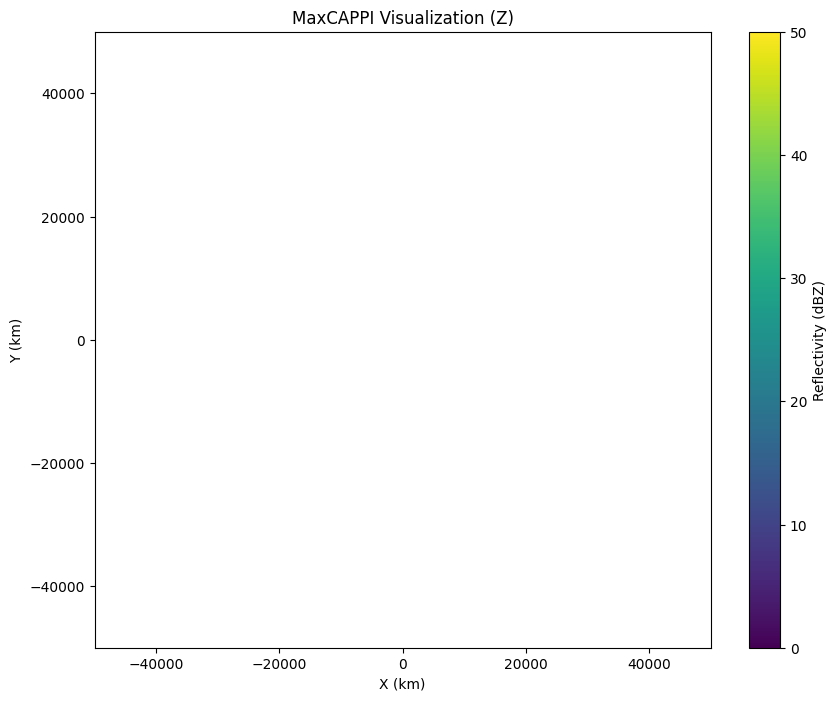

In [2]:
# Example radar volume data
vol = {
    'location': [49.0, 8.4, 100],  # [lat, lon, alt]
    'elevation': [0.5, 1.5, 2.5],  # Elevation angles
    'pixel_size': 1000,  # Pixel size in meters
    'Z': np.random.rand(3, 100, 100) * 50  # Simulated reflectivity data
}

# Call the function
maxcappigeo(vol, moment='Z', limits=[0, 50])